In [1]:
import sys
from pathlib import Path
from scipy.optimize import curve_fit
from typing import Literal, Dict, Any

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-05 16:02:04
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_LoB_AoC
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\On

In [2]:
LoB_AOC = pd.read_csv("LoB_AOC.csv")

In [5]:
LoB_AOC[['AOC conc','ct']]

,AOC conc,ct
0,25,34.489
1,25,35.379
2,25,37.458
3,25,NaN
4,25,NaN
5,25,NaN
6,25,34.874
7,25,36.231
8,100,31.784
9,100,31.815


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

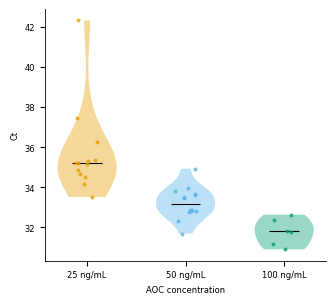

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- bin violin (strip + violin hybrid) ---
fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # 88mm single-col

groups = sorted(LoB_AOC["AOC conc"].unique())
colors = {"25": "#E69F00", "50": "#56B4E9", "100": "#009E73"}  # Okabe-Ito

for i, conc in enumerate(groups):
    vals = LoB_AOC.loc[LoB_AOC["AOC conc"] == conc, "ct"].dropna().values
    color = colors[str(int(conc))]

    # Violin
    parts = ax.violinplot(vals, positions=[i], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.4)
        pc.set_edgecolor("none")
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(0.8)

    # Jittered strip
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, s=8, alpha=0.8,
               linewidths=0, zorder=3)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels([f"{int(g)} ng/mL" for g in groups],
                   fontsize=6, fontname="Helvetica")
ax.set_ylabel("Ct", fontsize=6, fontname="Helvetica")
ax.set_xlabel("AOC concentration", fontsize=6, fontname="Helvetica")
ax.tick_params(axis="both", labelsize=6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
plt.savefig("LoB_AOC_violin.svg", dpi=300, bbox_inches="tight")
plt.show()